# IIR 滤波器类型对比

比较 scipy 提供的 5 种 IIR 滤波器设计方法的幅度响应。

| 滤波器 | 特点 |
|--------|------|
| Butterworth | 通带最平坦，滚降慢 |
| Chebyshev I | 通带有波纹，滚降较快 |
| Chebyshev II | 阻带有波纹，滚降较快 |
| Elliptic | 通带+阻带均有波纹，滚降最陡 |
| Bessel | 通带线性相位（群延迟最平坦），滚降最慢 |

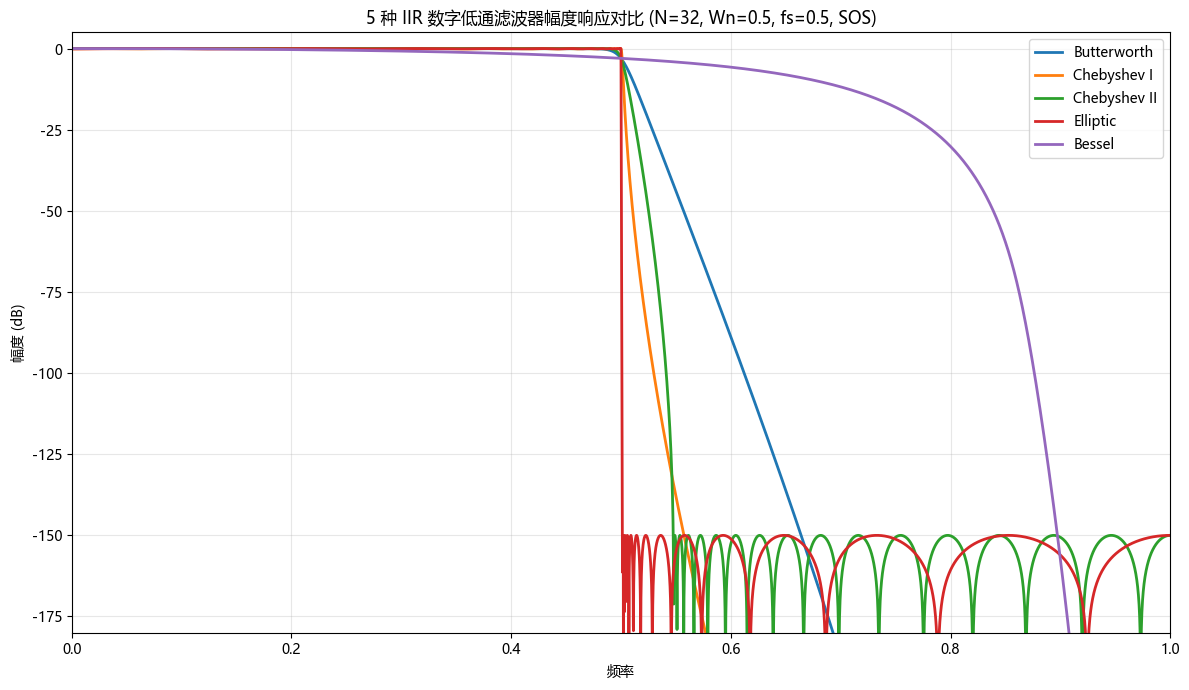

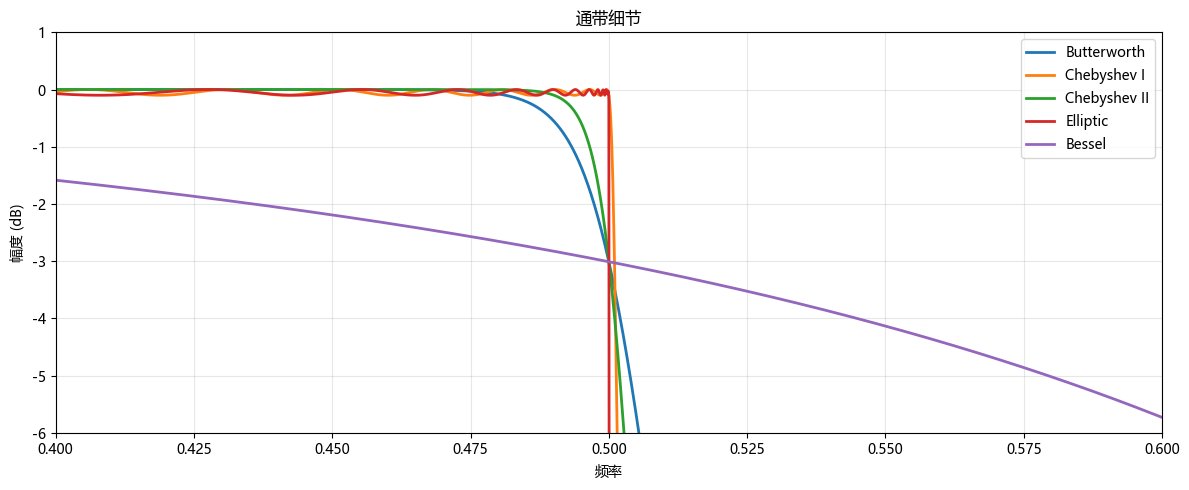

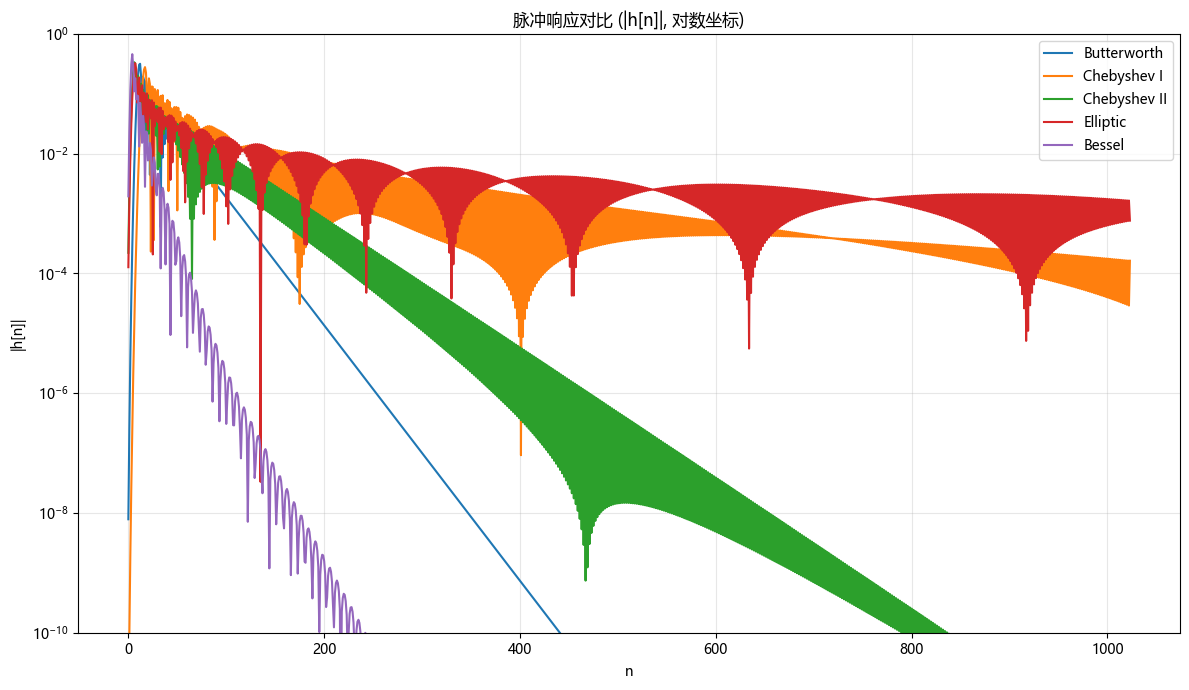

In [51]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

# ===== 滤波器相关系数（各滤波器参数独立） =====
# 格式: (阶数, 通带波纹dB, 阻带衰减dB, 截止频率Wn)
#       用 None 表示该滤波器无此参数

order_but  = 32;  rp_but  = None;  rs_but  = None;  wn_but  = 0.5
order_ch1  = 32;  rp_ch1  = 0.1;   rs_ch1  = None;  wn_ch1  = 0.5
order_ch2  = 32;  rp_ch2  = None;  rs_ch2  = 150;   wn_ch2  = 0.5
order_ell  = 32;  rp_ell  = 0.1;   rs_ell  = 150;   wn_ell  = 0.5
order_bes  = 32;  rp_bes  = None;  rs_bes  = None;  wn_bes  = 0.5

# 把切比雪夫2的截止频率设置为-3dB
atten = 3
fscale = np.cosh(np.acosh(np.sqrt((np.pow(10.0, rs_ch2 / 10.0) - 1.0) / (np.pow(10.0, atten / 10.0) - 1.0))) / (order_ch2))
wn_ch2 = np.atan(fscale) / (2 * np.pi)

# ===== 采样率（仅用于 freqz 的 x 轴） =====
fs = 2

# ===== 设计 5 种 IIR 数字低通滤波器 (SOS 形式) =====

sos_but = signal.butter(order_but, wn_but, btype='low', analog=False, output='sos')
sos_ch1 = signal.cheby1(order_ch1, rp_ch1, wn_ch1, btype='low', analog=False, output='sos')
sos_ch2 = signal.cheby2(order_ch2, rs_ch2, wn_ch2, fs=0.5, btype='low', analog=False, output='sos')
sos_ell = signal.ellip(order_ell, rp_ell, rs_ell, wn_ell, btype='low', analog=False, output='sos')
sos_bes = signal.bessel(order_bes, wn_bes, norm='mag', btype='low', analog=False, output='sos')

# ===== 频率响应计算 (sosfreqz) =====
filters = [
    ('Butterworth', sos_but, 'C0'),
    ('Chebyshev I', sos_ch1, 'C1'),
    ('Chebyshev II', sos_ch2, 'C2'),
    ('Elliptic',    sos_ell, 'C3'),
    ('Bessel',      sos_bes, 'C4'),
]

w_all, h_all = [], []
for _, sos, _ in filters:
    w, h = signal.sosfreqz(sos, worN=8192, fs=fs)
    w_all.append(w)
    h_all.append(h)

# ===== 幅度响应对比 =====
plt.figure(figsize=(12, 7))

for (name, _, color), w, h in zip(filters, w_all, h_all):
    mag_db = 20 * np.log10(np.abs(h) + 1e-15)
    plt.plot(w, mag_db, color=color, lw=2, label=name)

plt.title('5 种 IIR 数字低通滤波器幅度响应对比 (N=32, Wn=0.5, fs=0.5, SOS)')
plt.xlabel('频率')
plt.ylabel('幅度 (dB)')
plt.legend()
plt.grid(alpha=0.3)
plt.ylim(-180, 5)
plt.xlim(0, fs/2)
plt.tight_layout()
plt.show()

# ===== 通带细节 =====
plt.figure(figsize=(12, 5))
for (name, _, color), w, h in zip(filters, w_all, h_all):
    mag_db = 20 * np.log10(np.abs(h) + 1e-15)
    plt.plot(w, mag_db, color=color, lw=2, label=name)

plt.title('通带细节')
plt.xlabel('频率')
plt.ylabel('幅度 (dB)')
plt.legend()
plt.grid(alpha=0.3)
plt.ylim(-6, 1)
plt.xlim(0.4, 0.6)
plt.tight_layout()
plt.show()

# ===== 脉冲响应（对数 y 轴） =====
N_imp = 1024
impulse = np.zeros(N_imp)
impulse[0] = 1.0

plt.figure(figsize=(12, 7))
for (name, sos, color) in filters:
    h_imp = signal.sosfilt(sos, impulse)
    plt.semilogy(np.abs(h_imp) + 1e-20, color=color, lw=1.5, label=name)

plt.title('脉冲响应对比 (|h[n]|, 对数坐标)')
plt.xlabel('n')
plt.ylabel('|h[n]|')
plt.legend()
plt.grid(alpha=0.3, which='both')
plt.ylim(1e-10, 1)
plt.tight_layout()
plt.show()